In [4]:
import mne

In [5]:
import matplotlib.pyplot as plt

In [6]:
sample_data_folder = mne.datasets.sample.data_path()
raw_file = sample_data_folder / "MEG" / "sample" / "sample_audvis_raw.fif"


In [7]:
raw = mne.io.read_raw_fif(raw_file, preload=True)

Opening raw data file /Users/anushka.j/mne_data/MNE-sample-data/MEG/sample/sample_audvis_raw.fif...
    Read a total of 3 projection items:
        PCA-v1 (1 x 102)  idle
        PCA-v2 (1 x 102)  idle
        PCA-v3 (1 x 102)  idle
    Range : 25800 ... 192599 =     42.956 ...   320.670 secs
Ready.
Reading 0 ... 166799  =      0.000 ...   277.714 secs...


In [8]:
print(raw)
print(raw.info)

<Raw | sample_audvis_raw.fif, 376 x 166800 (277.7 s), ~481.7 MiB, data loaded>
<Info | 21 non-empty values
 acq_pars: ACQch001 110113 ACQch002 110112 ACQch003 110111 ACQch004 110122 ...
 bads: 2 items (MEG 2443, EEG 053)
 ch_names: MEG 0113, MEG 0112, MEG 0111, MEG 0122, MEG 0123, MEG 0121, MEG ...
 chs: 204 Gradiometers, 102 Magnetometers, 9 Stimulus, 60 EEG, 1 EOG
 custom_ref_applied: False
 description: acquisition (megacq) VectorView system at NMR-MGH
 dev_head_t: MEG device -> head transform
 dig: 146 items (3 Cardinal, 4 HPI, 61 EEG, 78 Extra)
 events: 1 item (list)
 experimenter: MEG
 file_id: 4 items (dict)
 highpass: 0.1 Hz
 hpi_meas: 1 item (list)
 hpi_results: 1 item (list)
 lowpass: 172.2 Hz
 meas_date: 2002-12-03 19:01:10 UTC
 meas_id: 4 items (dict)
 nchan: 376
 proj_id: 1
 proj_name: test
 projs: PCA-v1: off, PCA-v2: off, PCA-v3: off
 sfreq: 600.6 Hz
>


In [9]:
raw.pick("eeg")


<Raw | sample_audvis_raw.fif, 60 x 166800 (277.7 s), ~79.3 MiB, data loaded>

Using matplotlib as 2D backend.


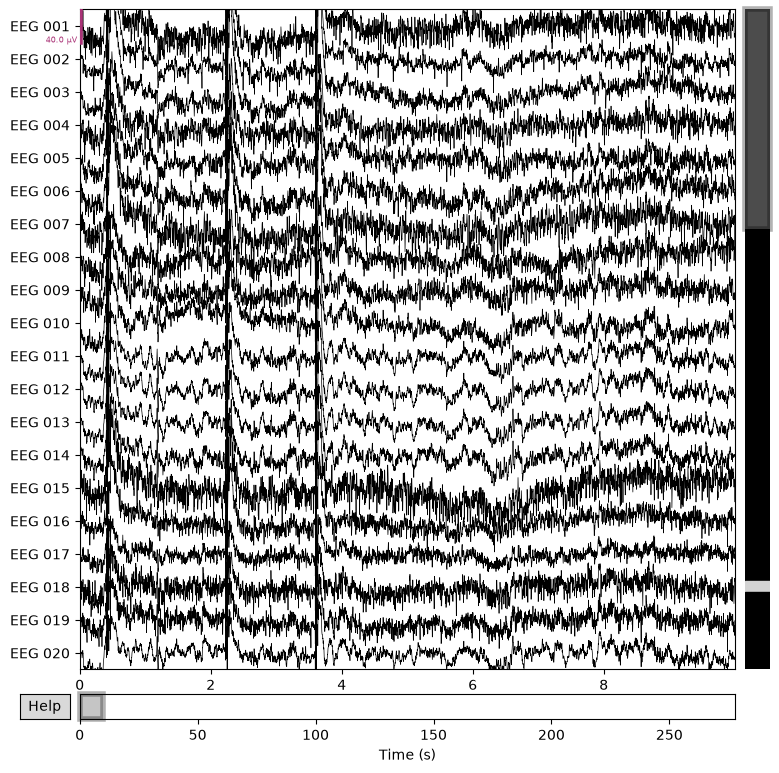

In [10]:
raw.plot()
plt.show()

In [11]:
montage = mne.channels.make_standard_montage("standard_1020")
raw.set_montage(montage, match_case=False, on_missing="ignore")

<Raw | sample_audvis_raw.fif, 60 x 166800 (277.7 s), ~79.2 MiB, data loaded>

In [14]:
raw_filtered = raw.copy().filter(l_freq=1, h_freq=40)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 40 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 40.00 Hz
- Upper transition bandwidth: 10.00 Hz (-6 dB cutoff frequency: 45.00 Hz)
- Filter length: 1983 samples (3.302 s)



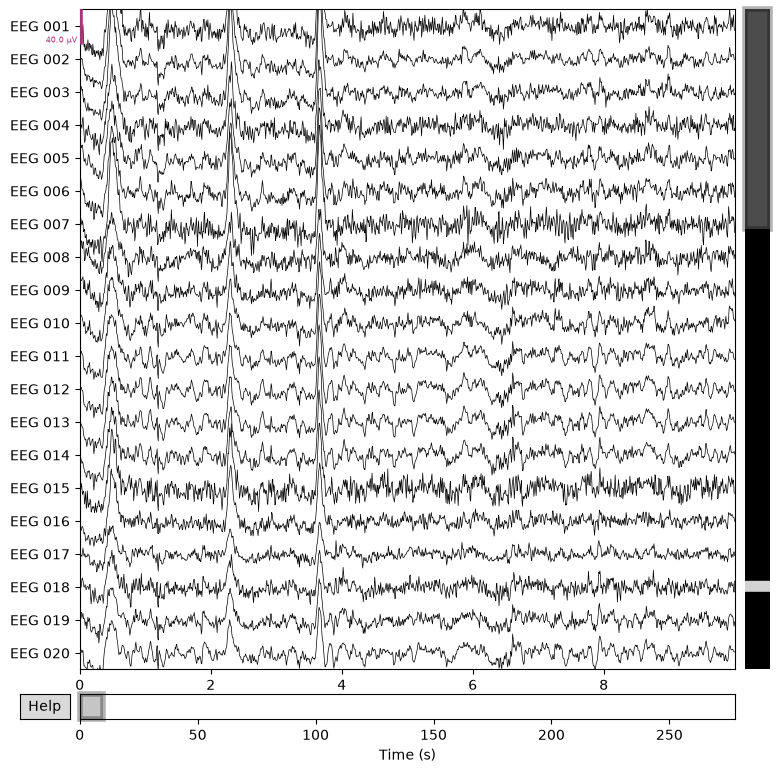

In [15]:
raw_filtered.plot()
plt.show()

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/Users/anushka.j/Desktop/matplotlib-workspace/.venv/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


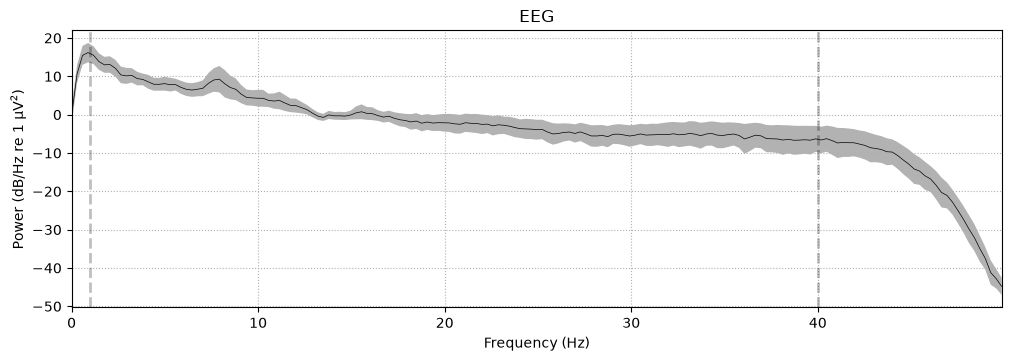

In [17]:
spectrum = raw_filtered.compute_psd(fmax=50)
spectrum.plot(average=True, picks="data", exclude="bads", amplitude=False)
plt.show()

In [18]:
import matplotlib as mpl

In [19]:
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman", "DejaVu Serif"]  # falls back if TNR isn't installed
mpl.rcParams["font.size"] = 12

In [20]:
nice_blue = "#1f4e8c"

In [21]:
spectrum = raw_filtered.compute_psd(fmax=50)
fig = spectrum.plot(average=True, picks="data", exclude="bads", amplitude=False)

Effective window size : 3.410 (s)
Plotting power spectral density (dB=True).


/Users/anushka.j/Desktop/matplotlib-workspace/.venv/lib/python3.14/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


In [23]:
ax = fig.axes[0]                      #plot's axes
for line in ax.get_lines():
    line.set_color(nice_blue)         # the main PSD curve
ax.set_title("EEG Power Spectral Density", color=nice_blue, fontsize=14, weight="bold")
ax.tick_params(colors="#333333")      # subtle dark-grey ticks
for spine in ax.spines.values():
    spine.set_edgecolor(nice_blue)    # the border in blue

/var/folders/z7/rv1tgvq91gl4wcd8nyz8v3100000gn/T/ipykernel_73843/317609030.py:1: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


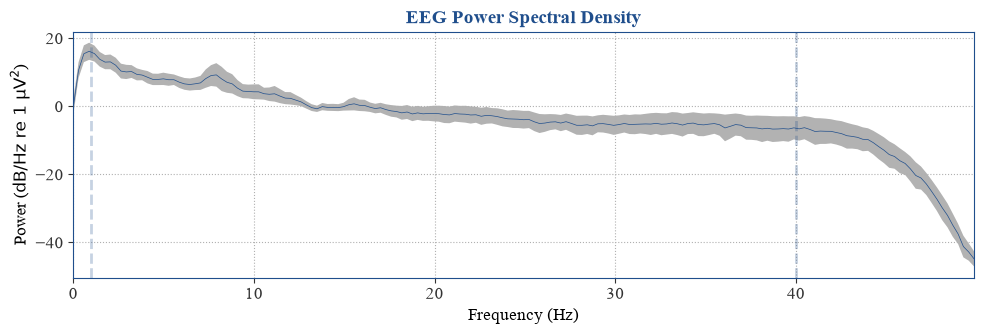

In [24]:
fig.tight_layout()
plt.show()

In [25]:
fig.savefig("psd_plot.png", dpi=300, bbox_inches="tight")